# Example (Use of Information Gain)

## **How Information Gain is Used in Decision Trees**
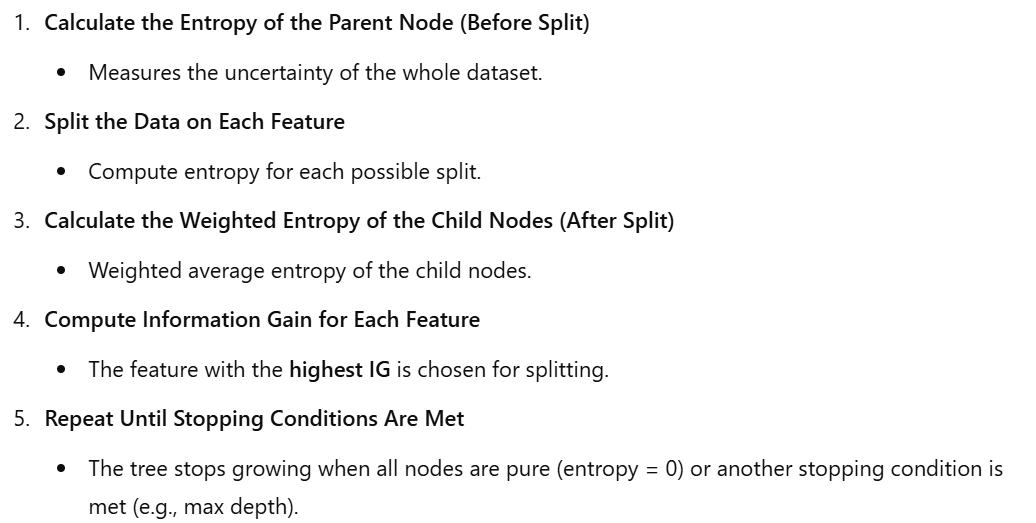

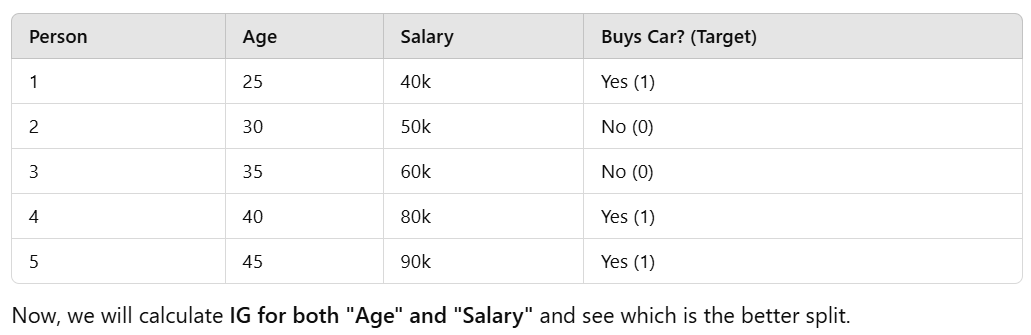

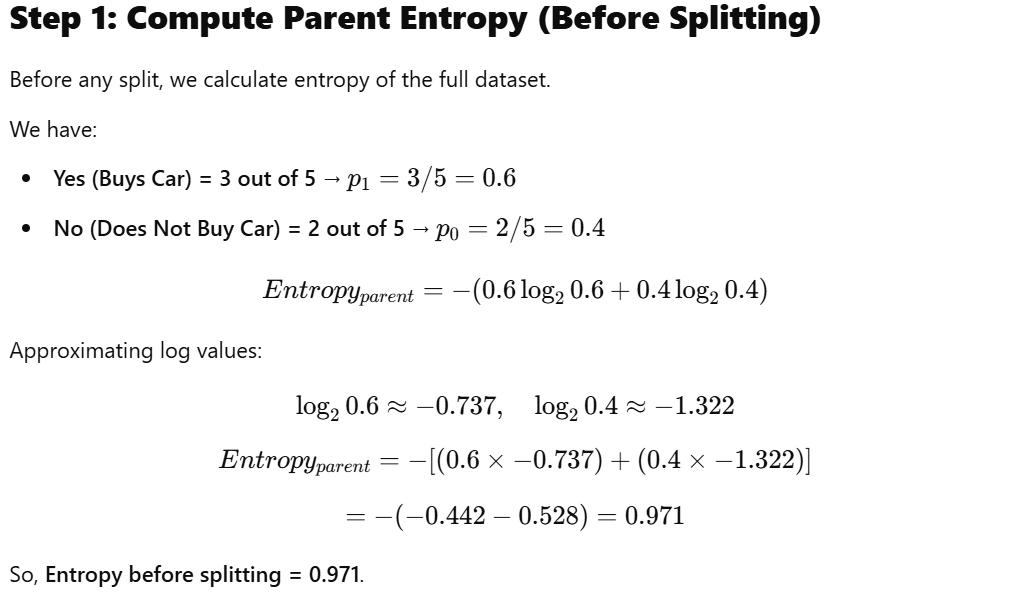

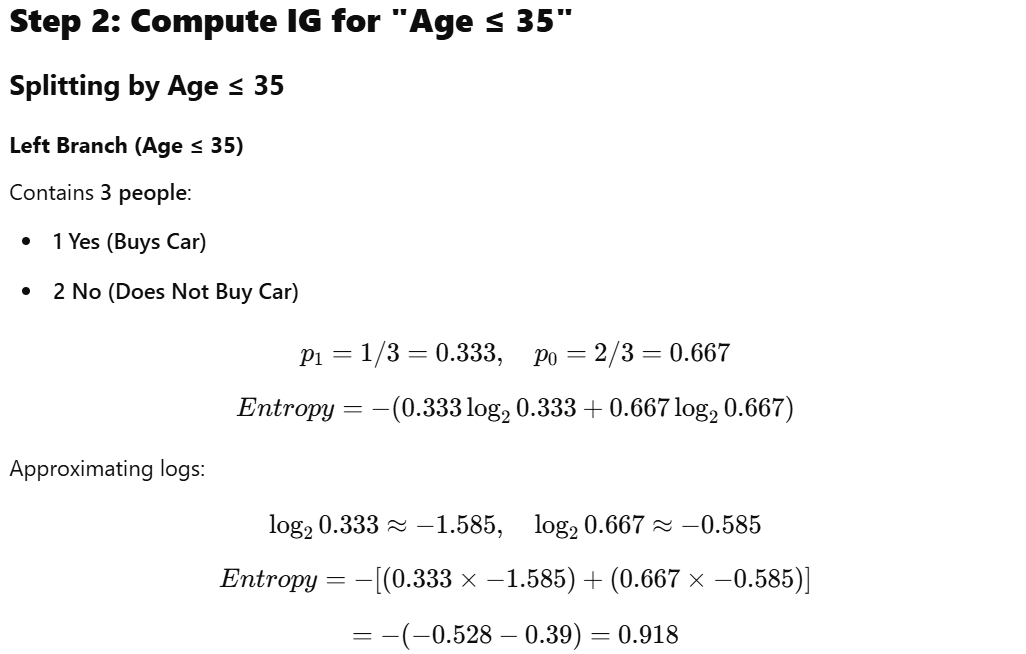

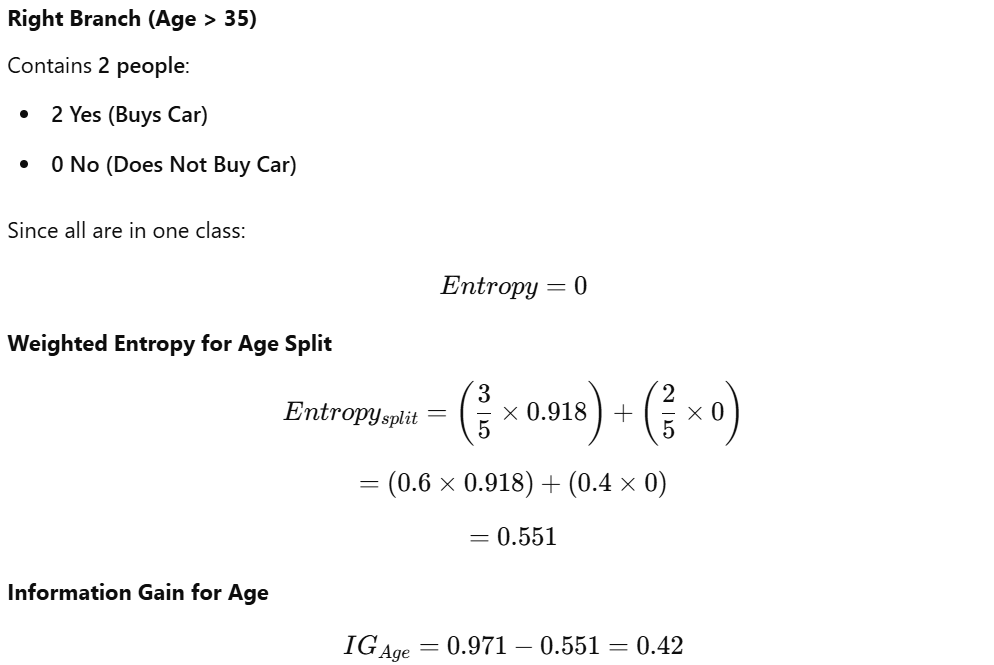

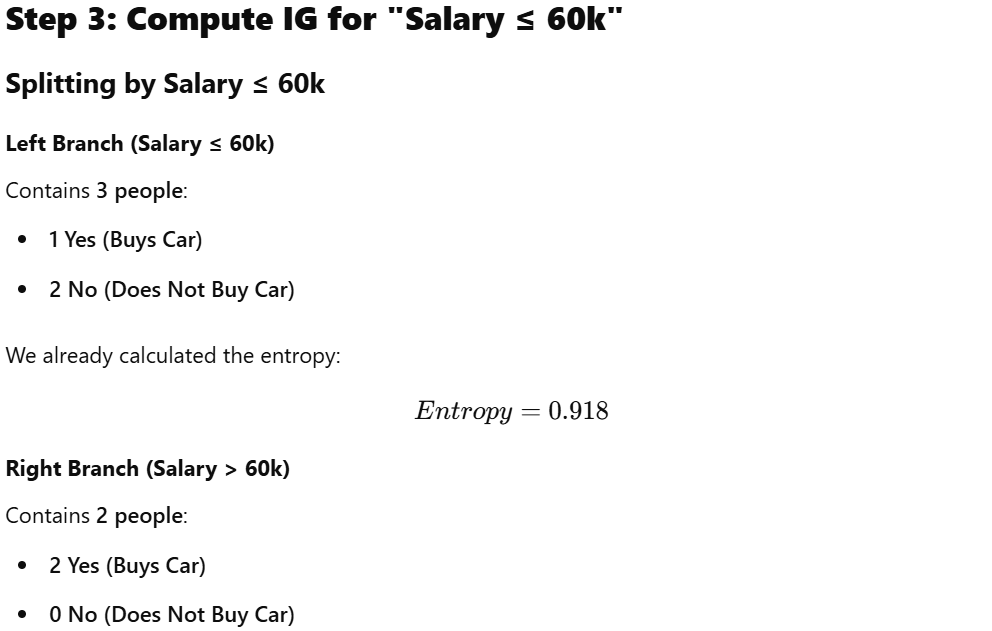

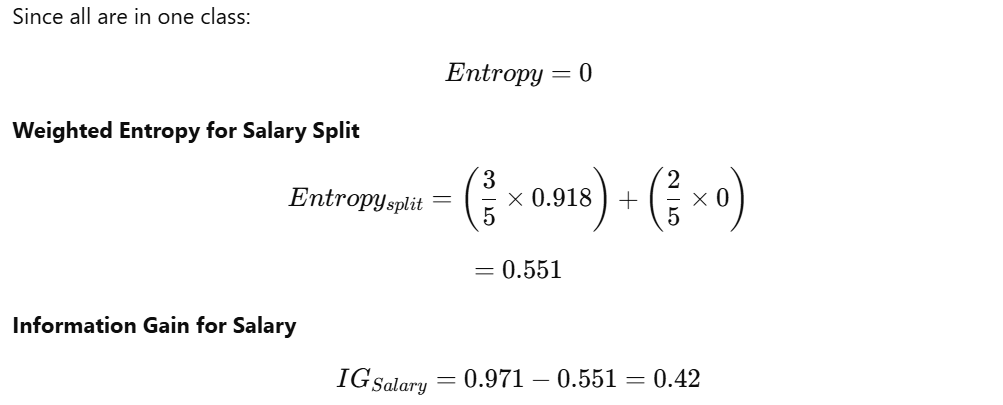

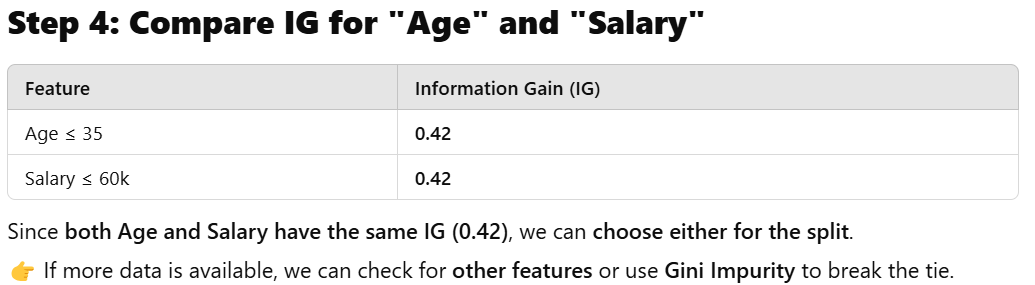

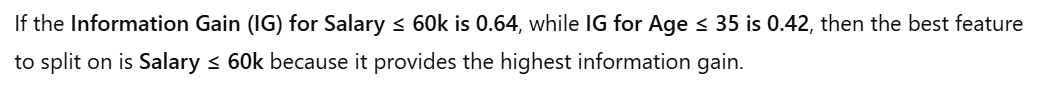

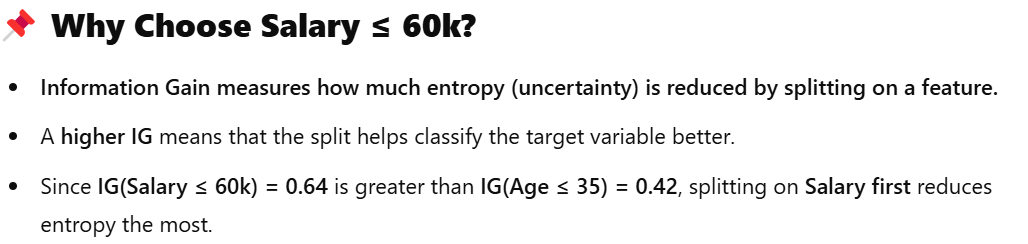

In [1]:
## Importing all the libraries
import pandas as pd
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('dataset.csv')

In [3]:
df

,Age,Weight,No of Injuries,Results
0,32,200,0,1
1,28,143,0,1
2,25,150,1,0
3,29,220,1,0
4,36,196,3,1


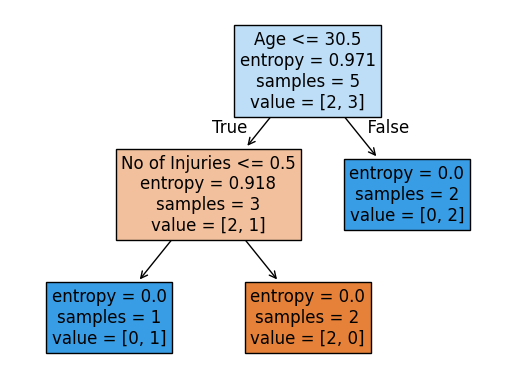

In [4]:
X = df[['Age','Weight','No of Injuries']]
y = df['Results']
features=['Age','Weight','No of Injuries']

## Fitting the model
dtree = DecisionTreeClassifier(criterion="entropy")
dtree = dtree.fit(X, y)

## Ploting the tree
plot_tree(dtree, feature_names=features, filled=True, fontsize=12)
plt.show()

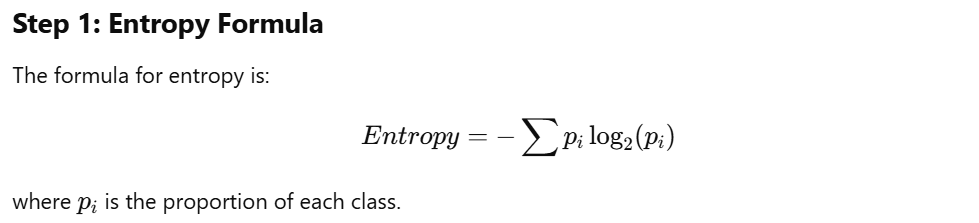

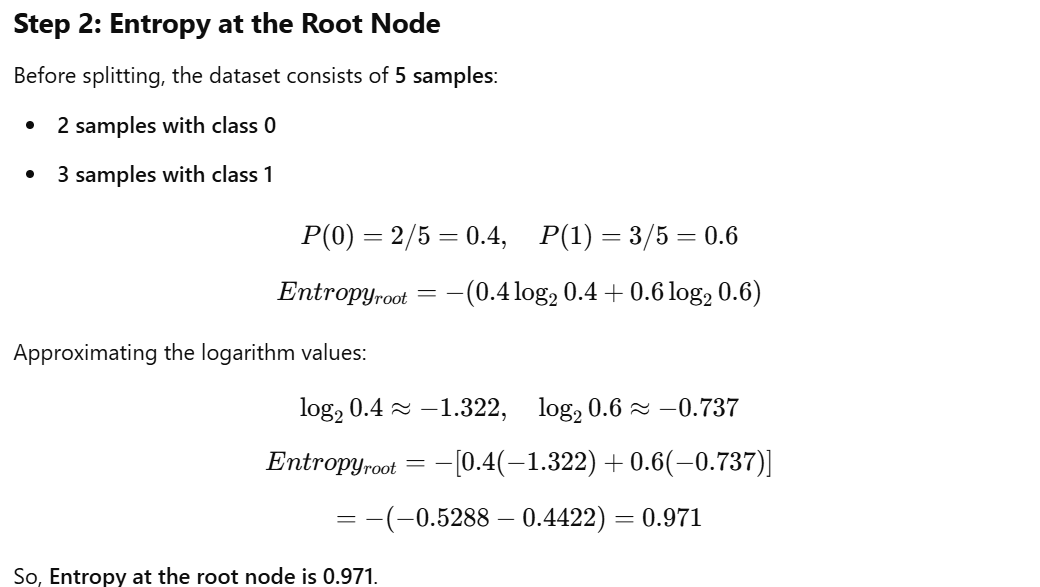

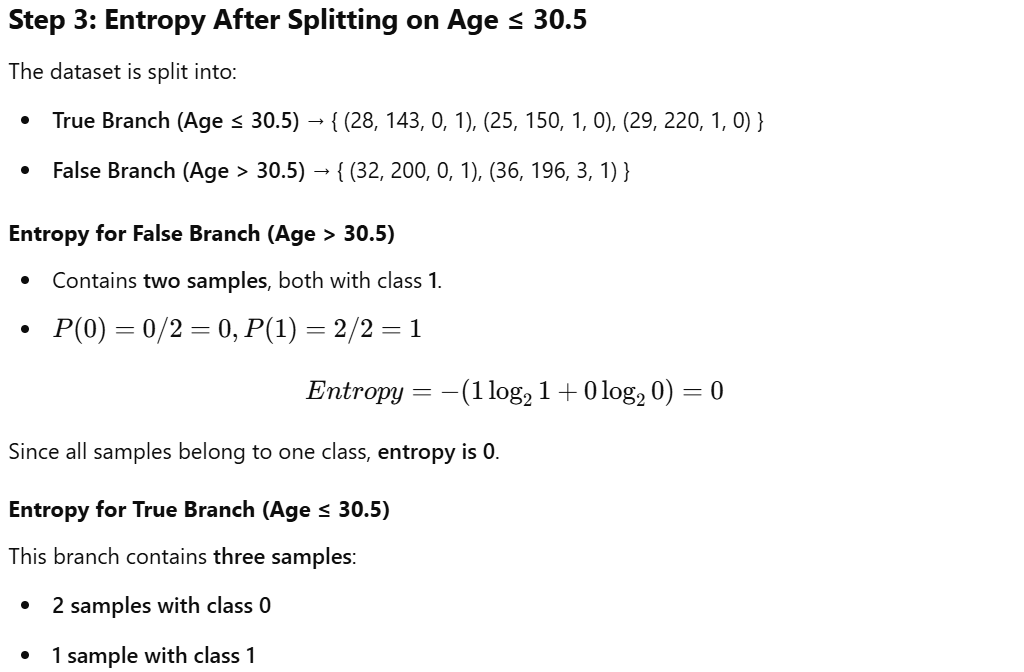

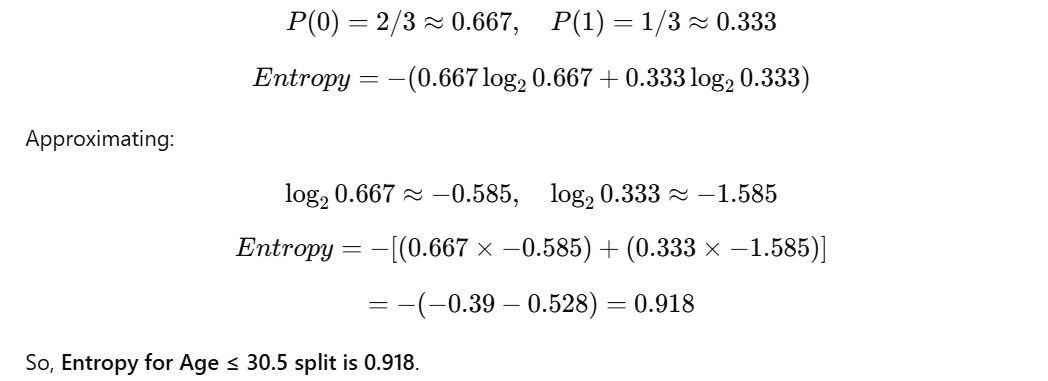

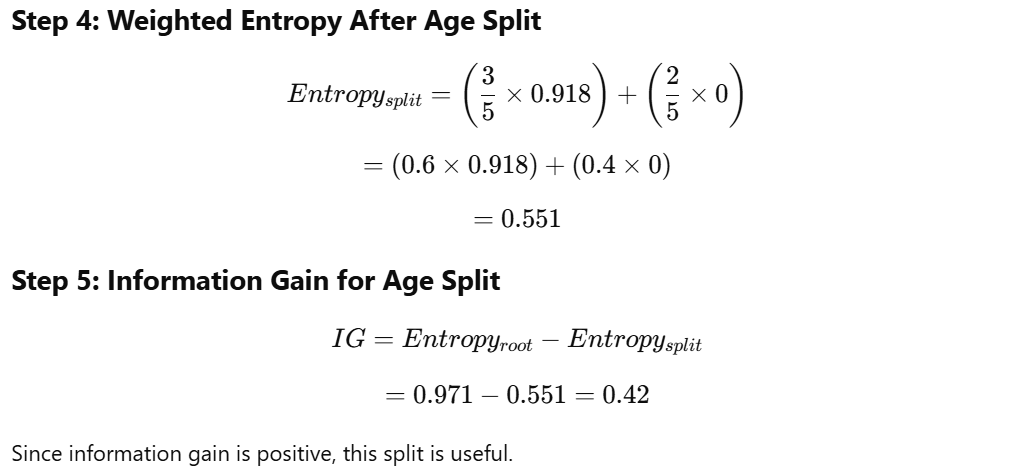

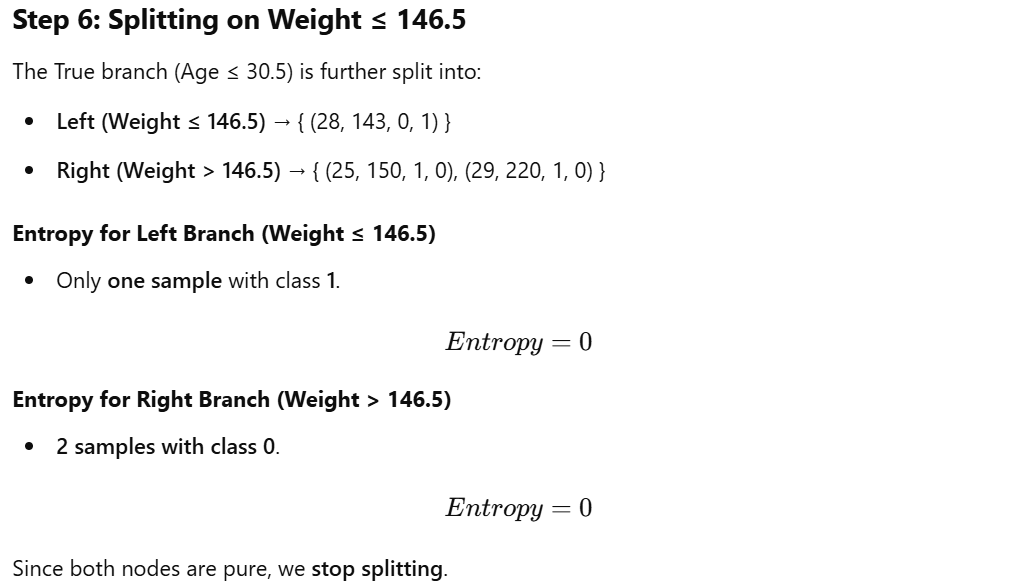

# Gini Impurity

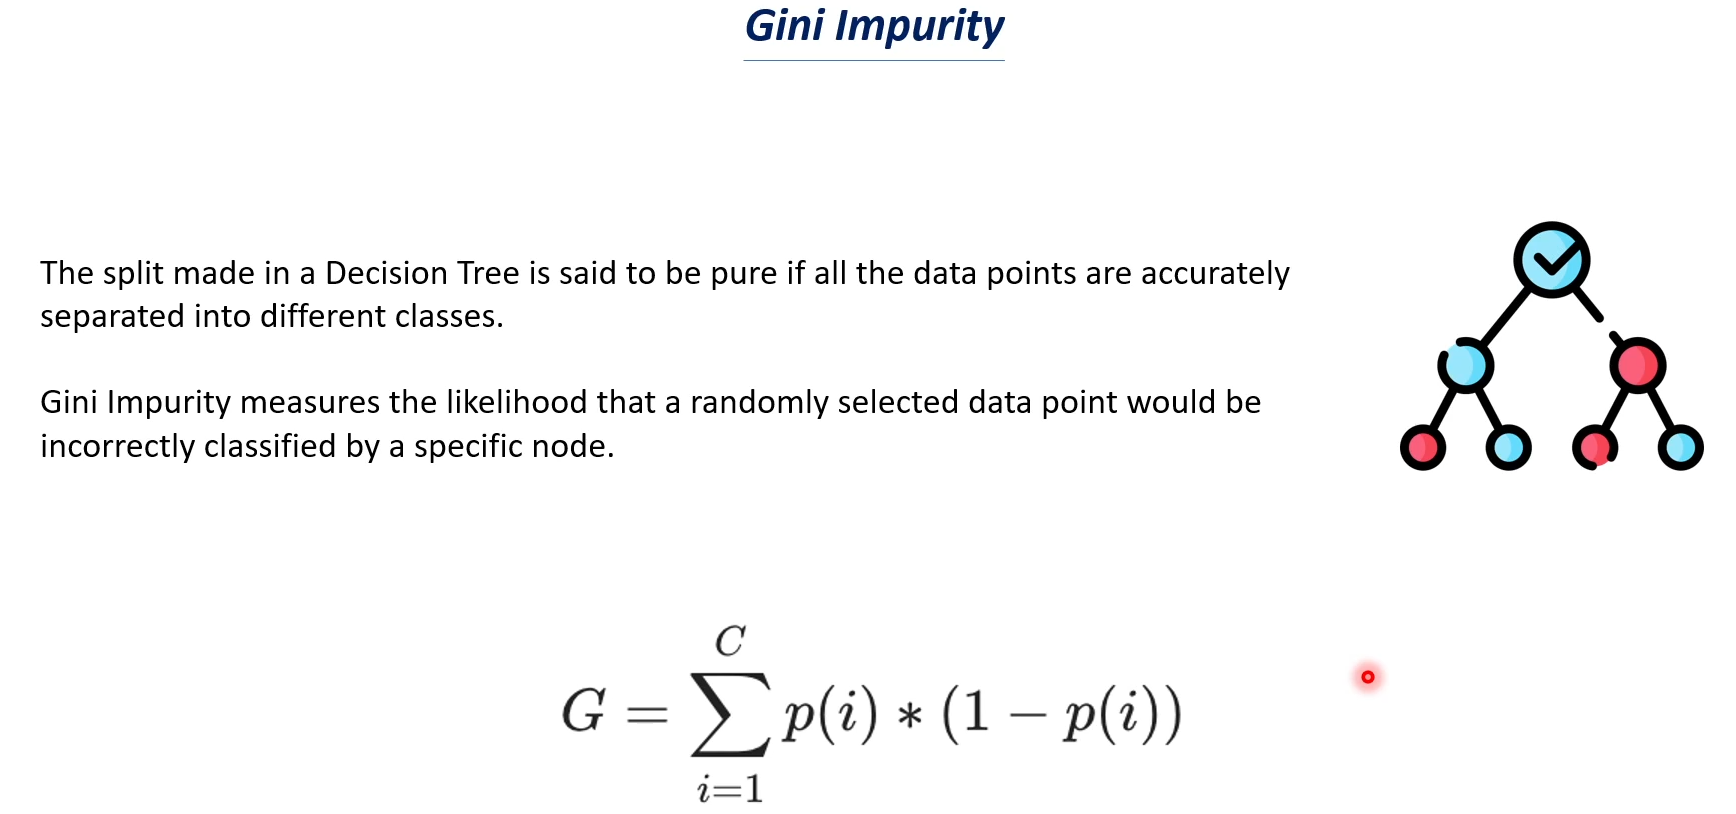

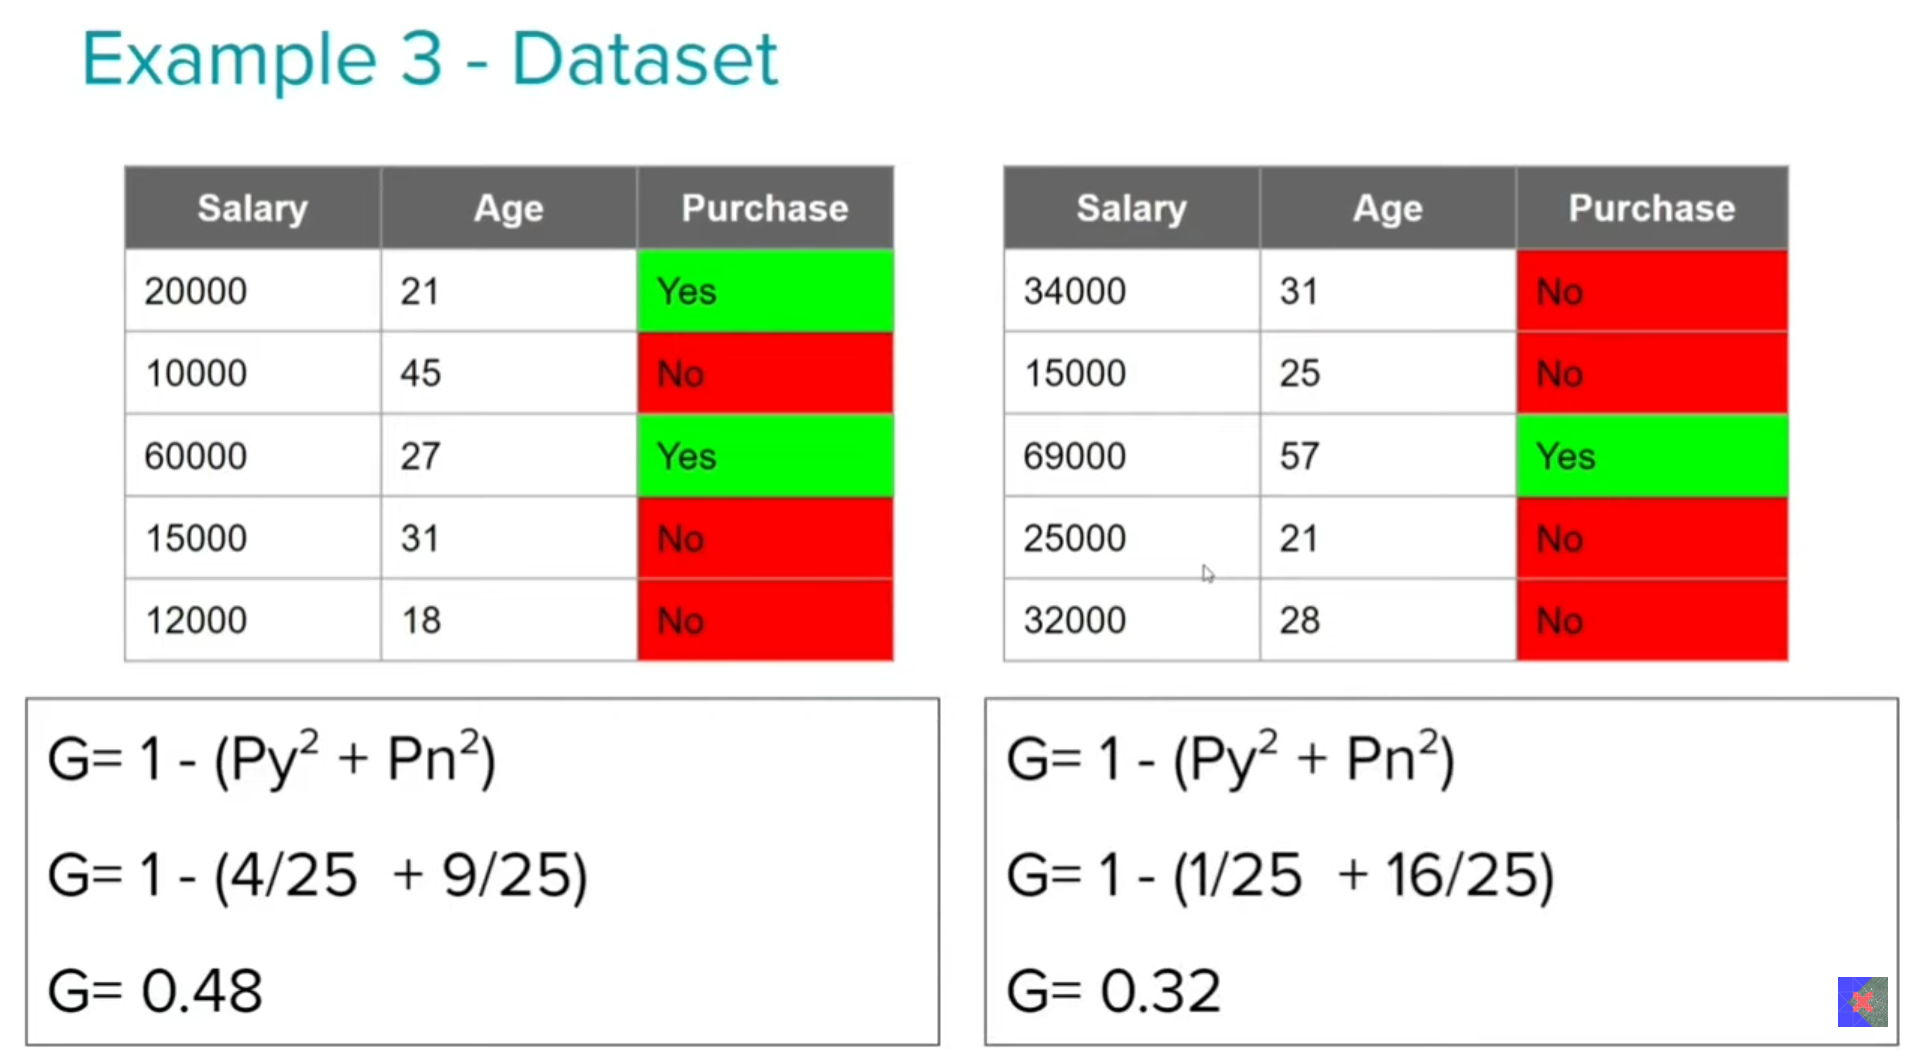

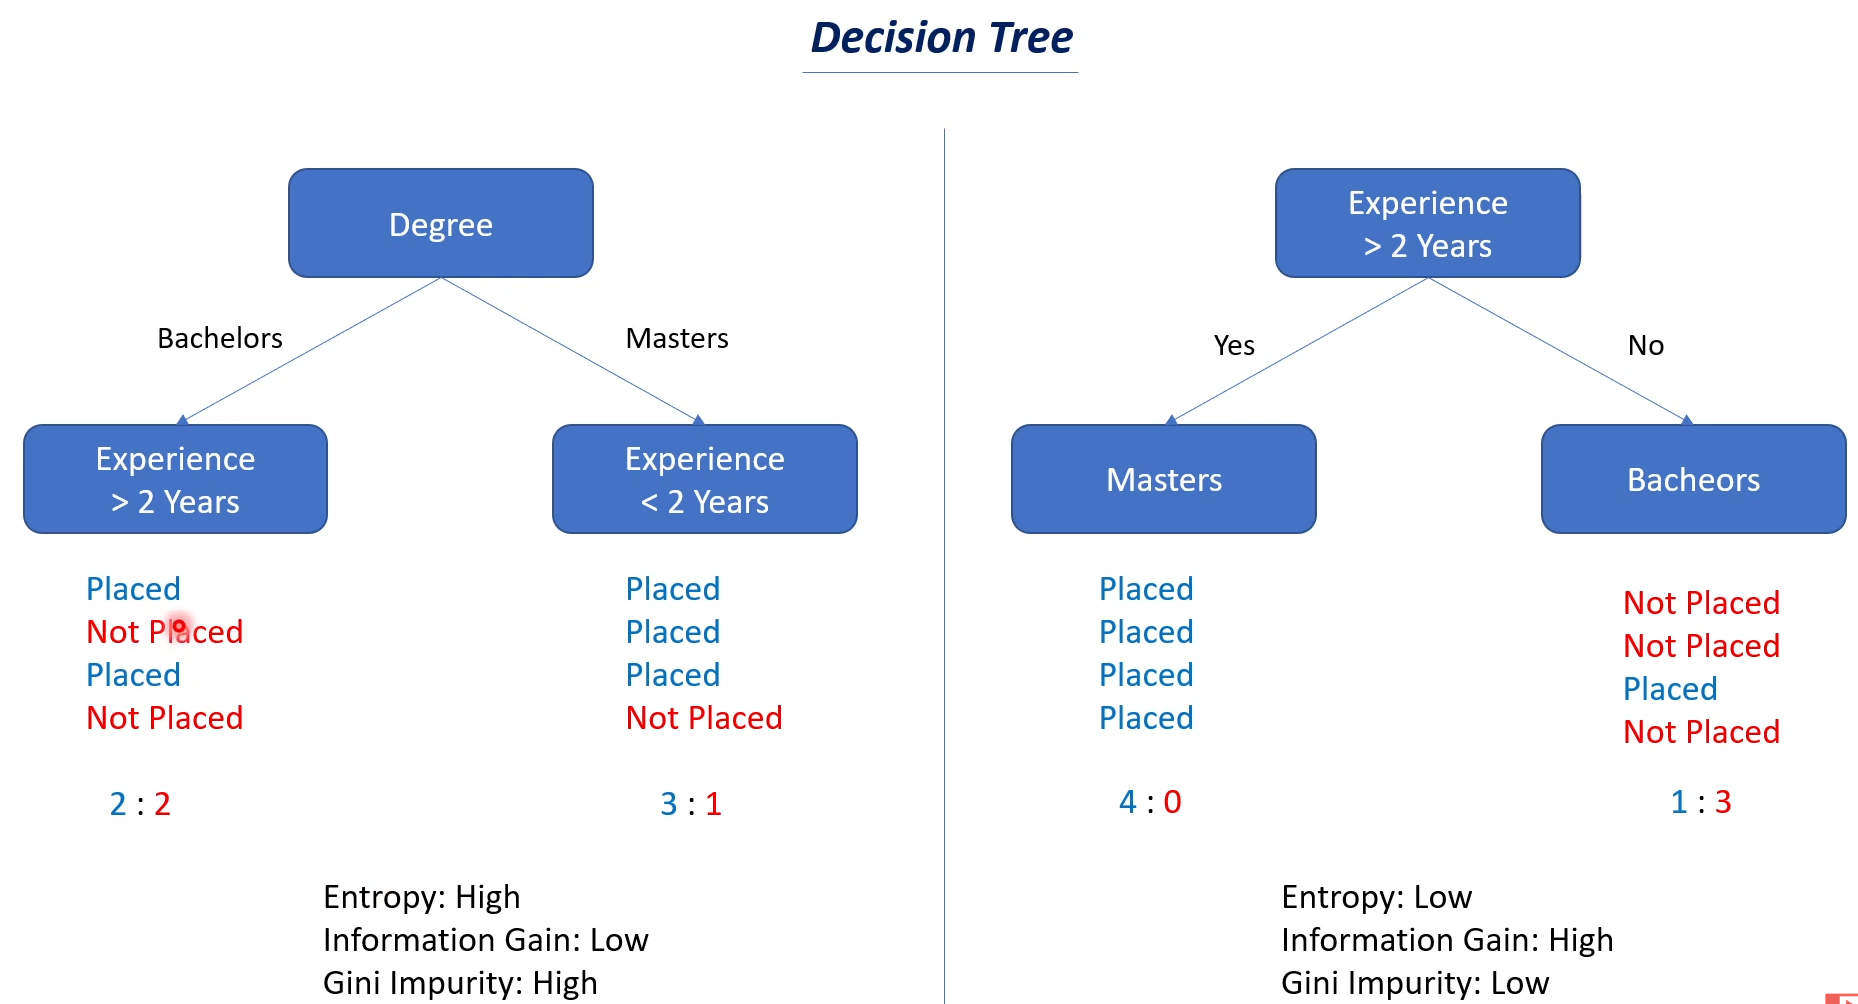

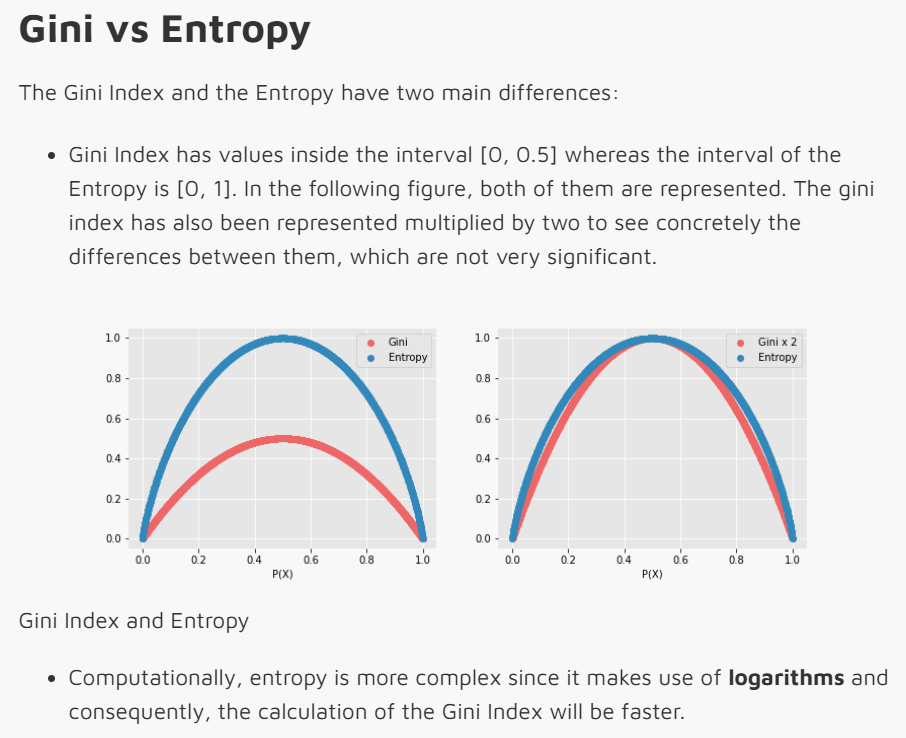

# Handling numerical data

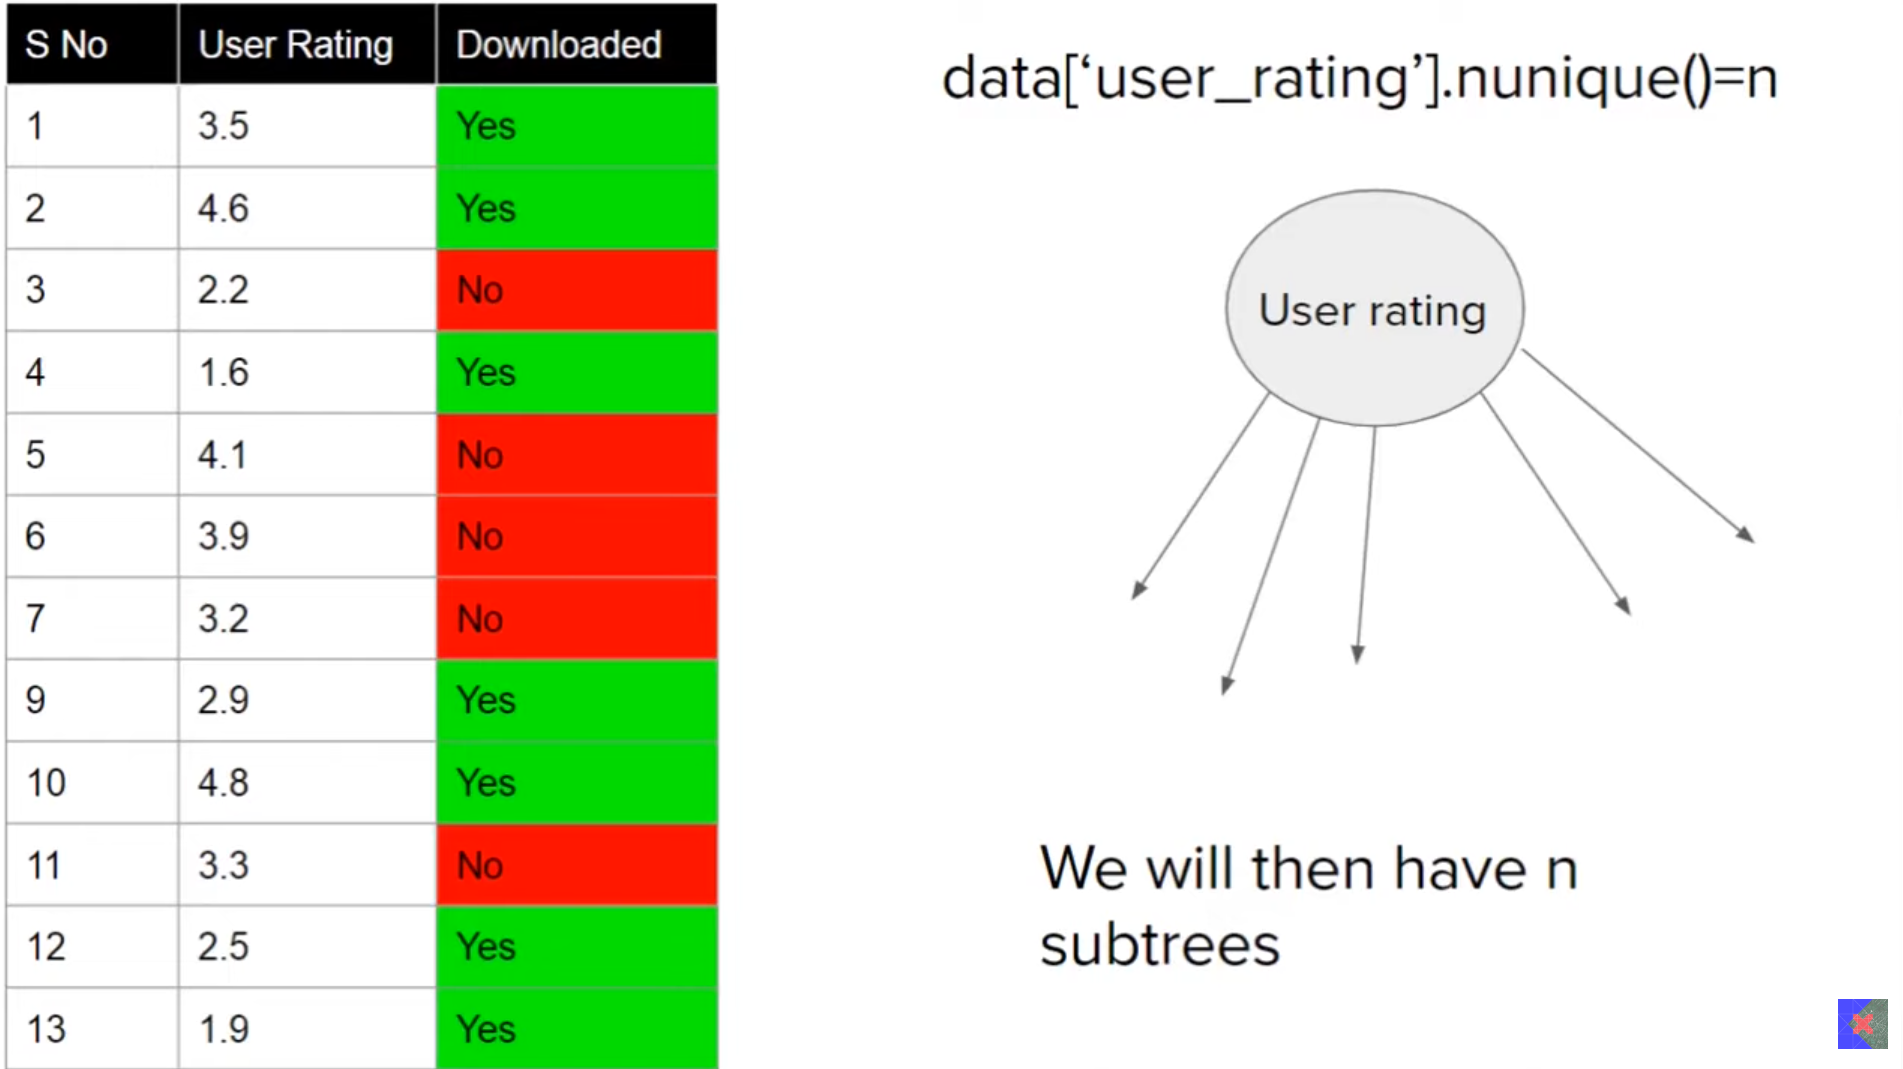

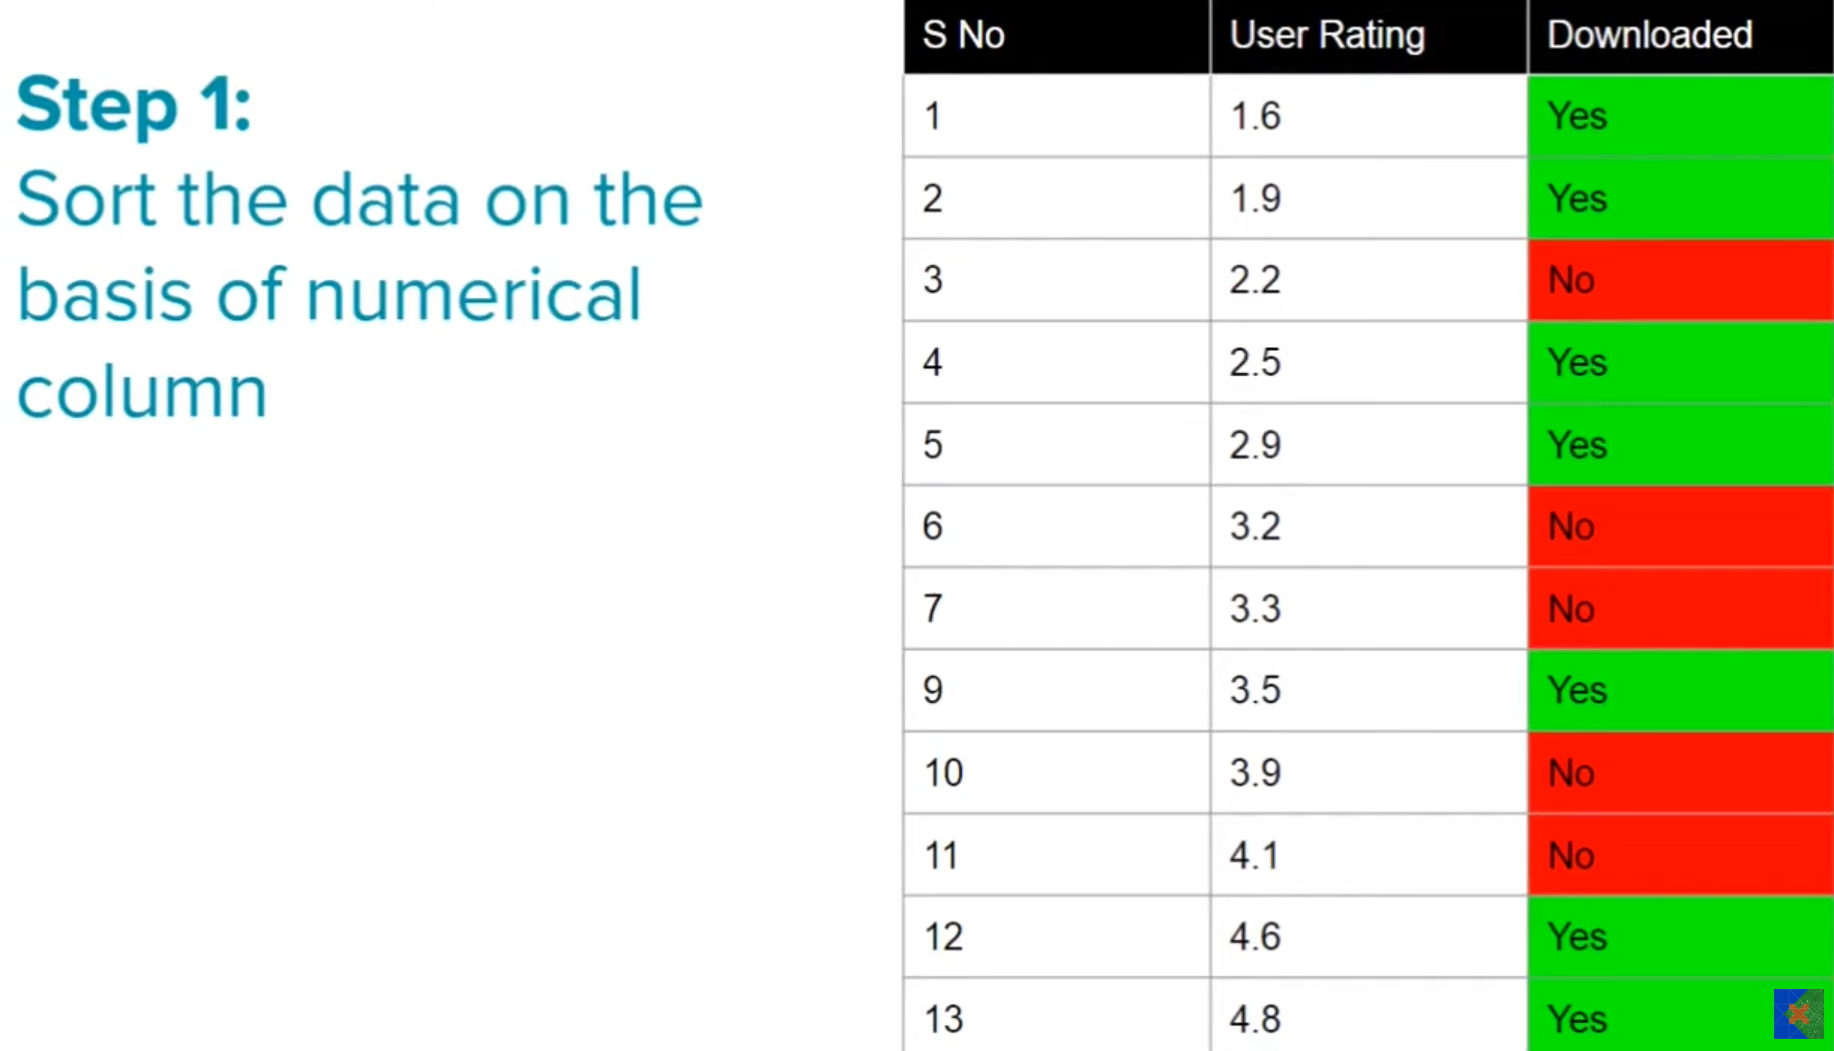

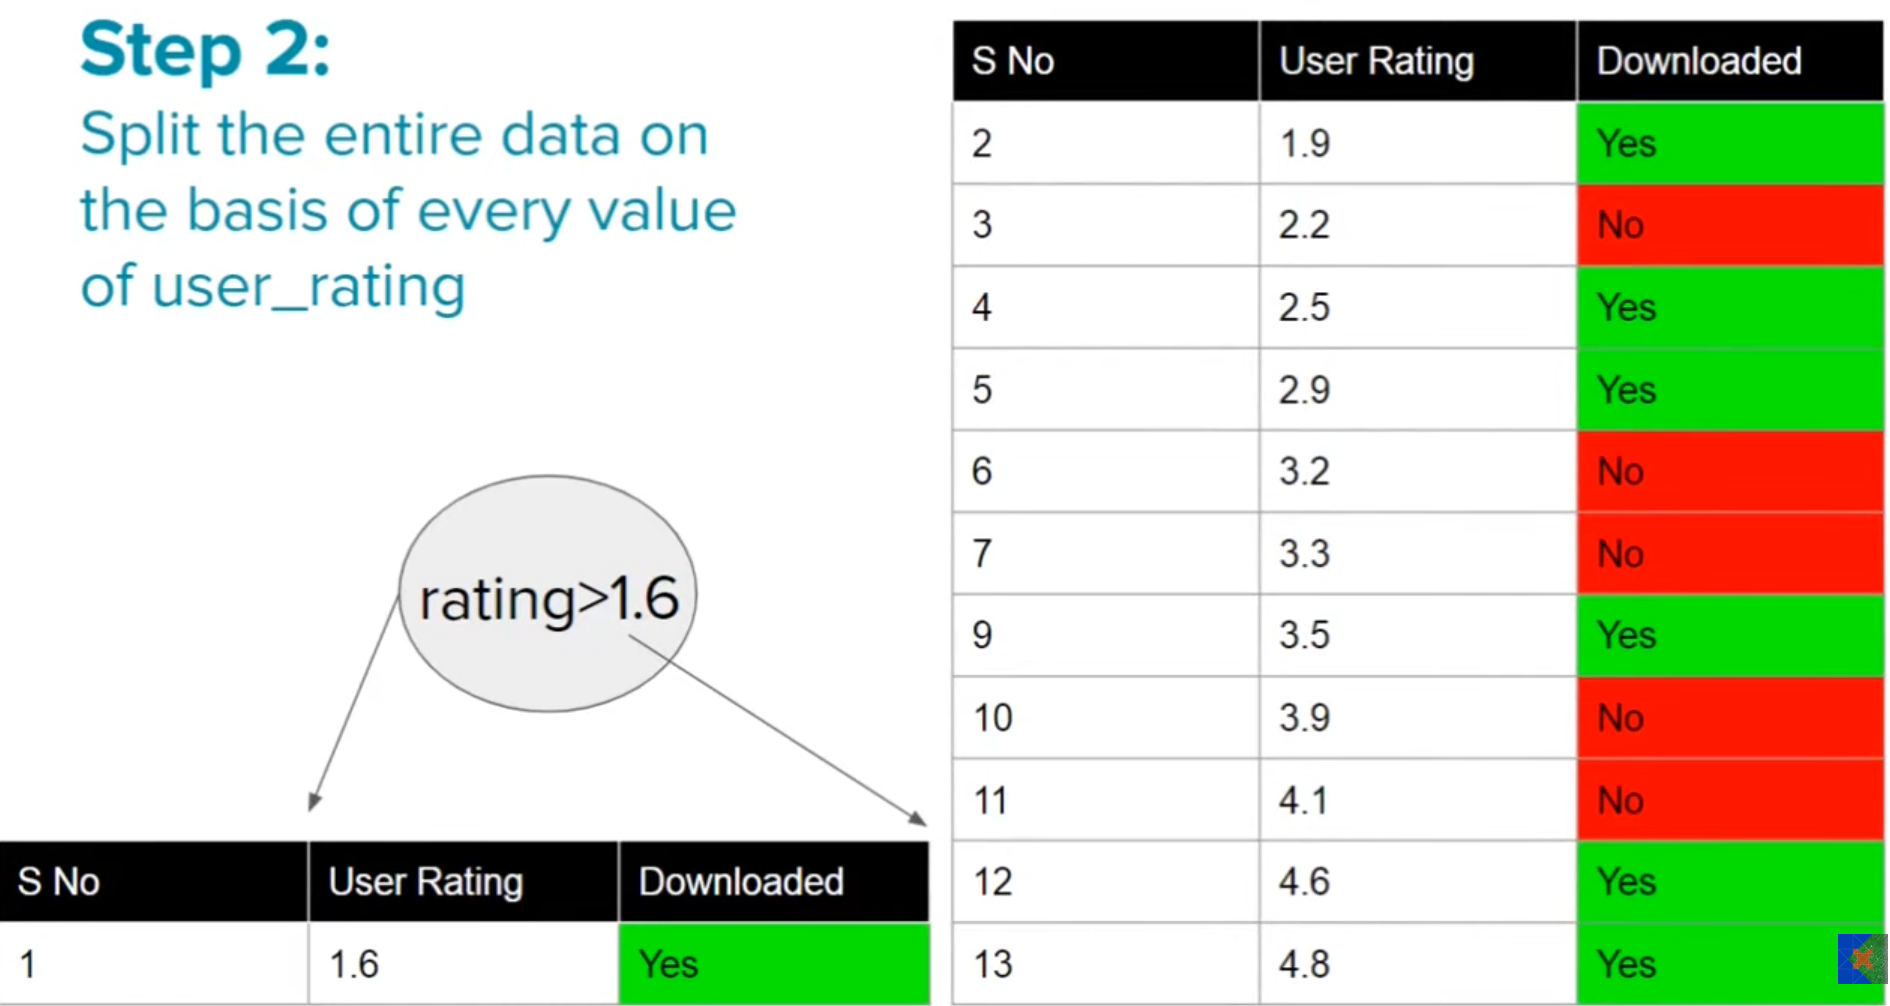

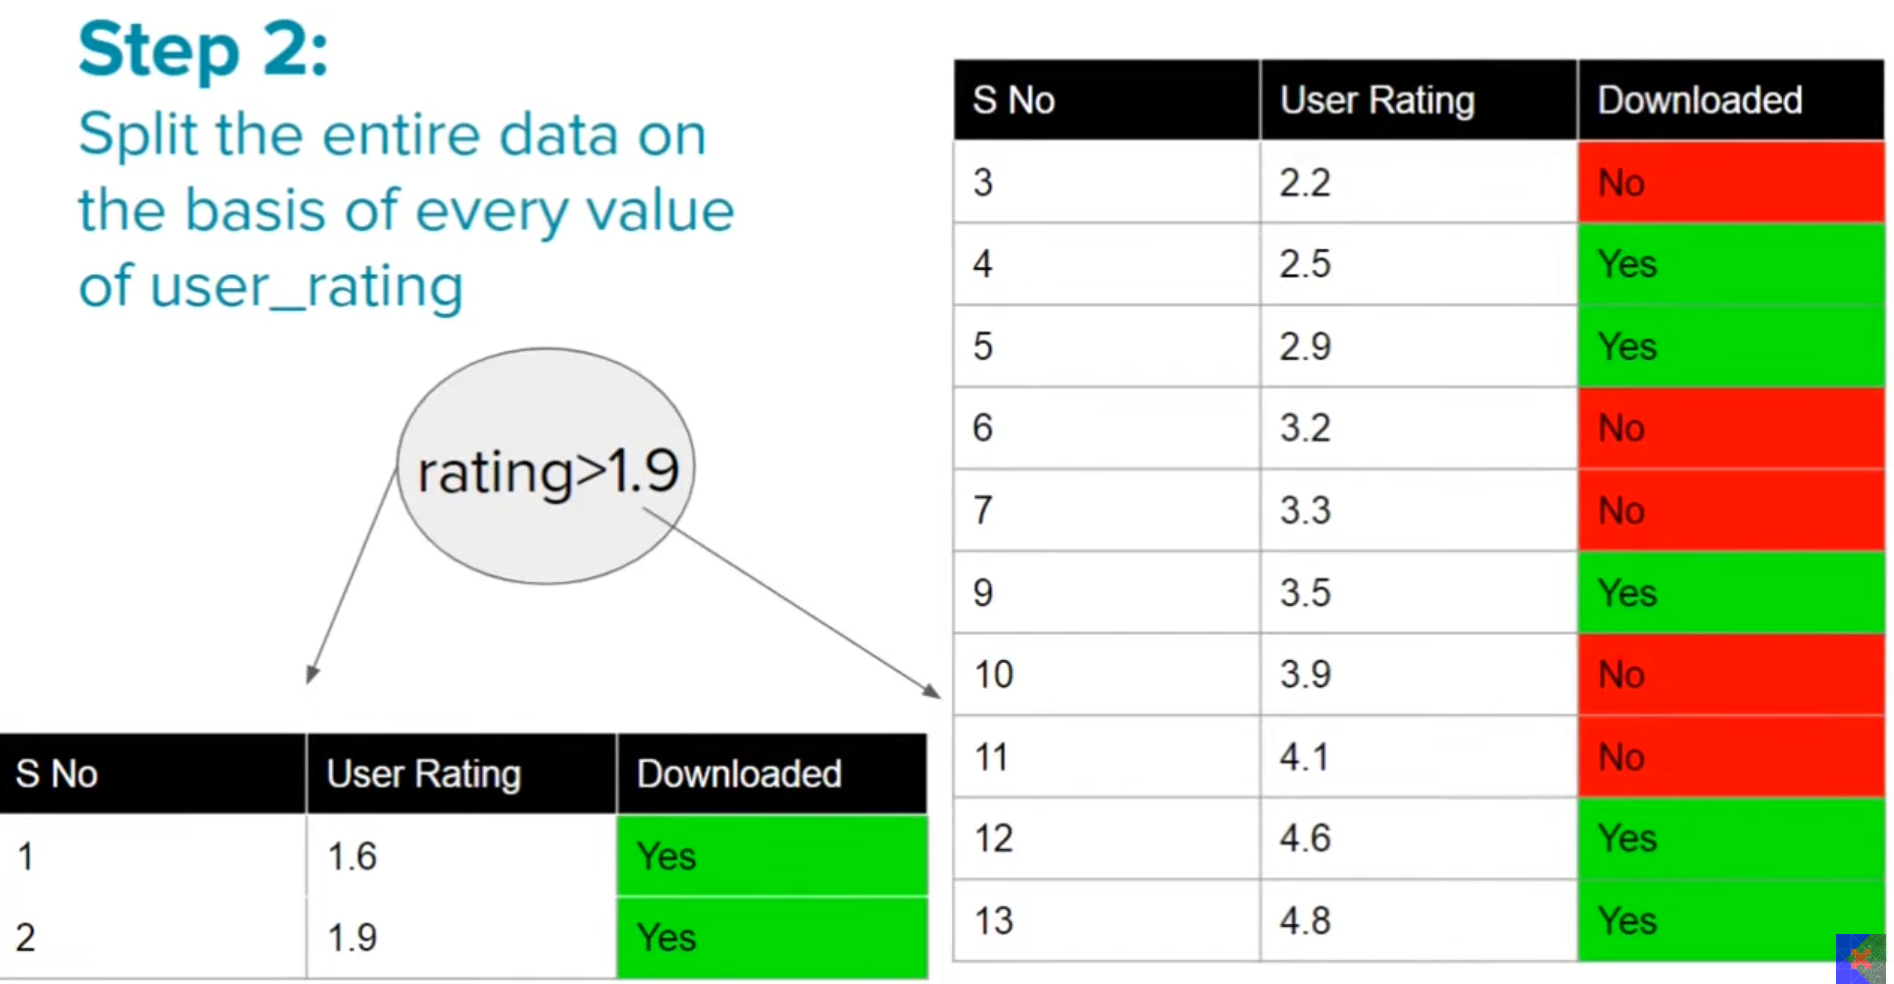

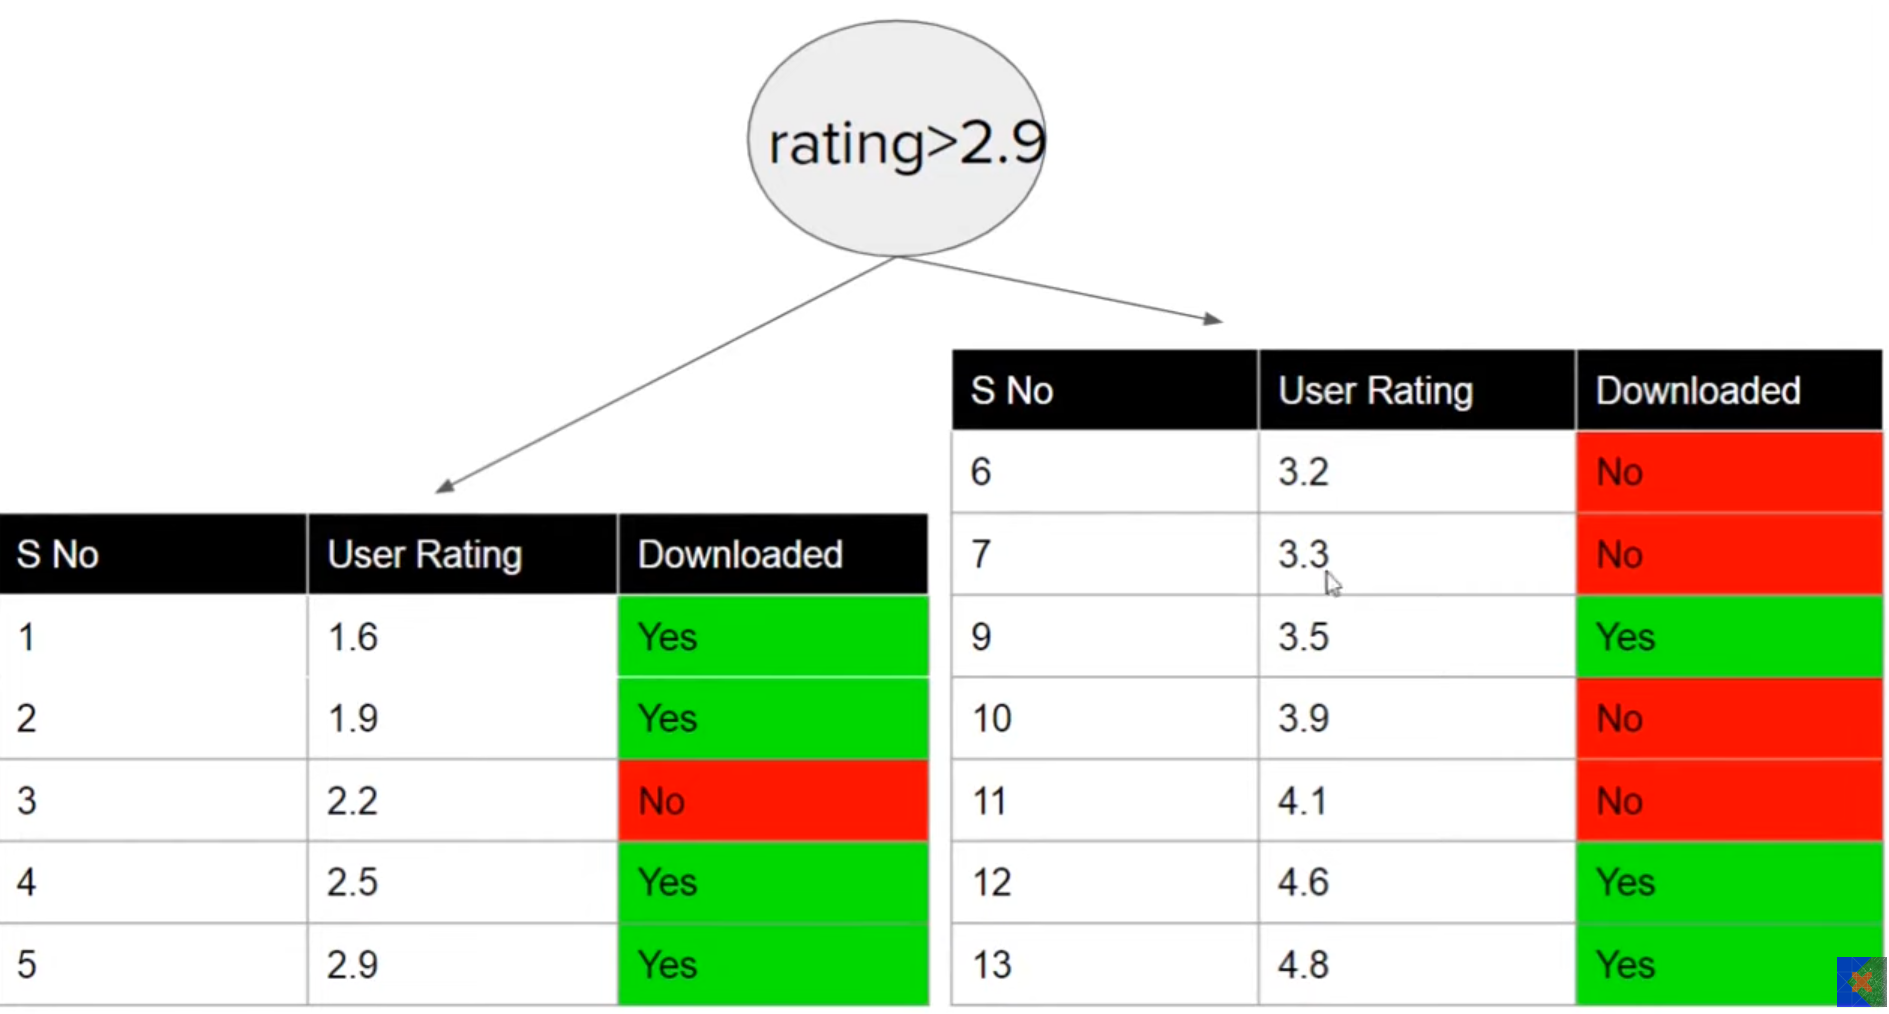

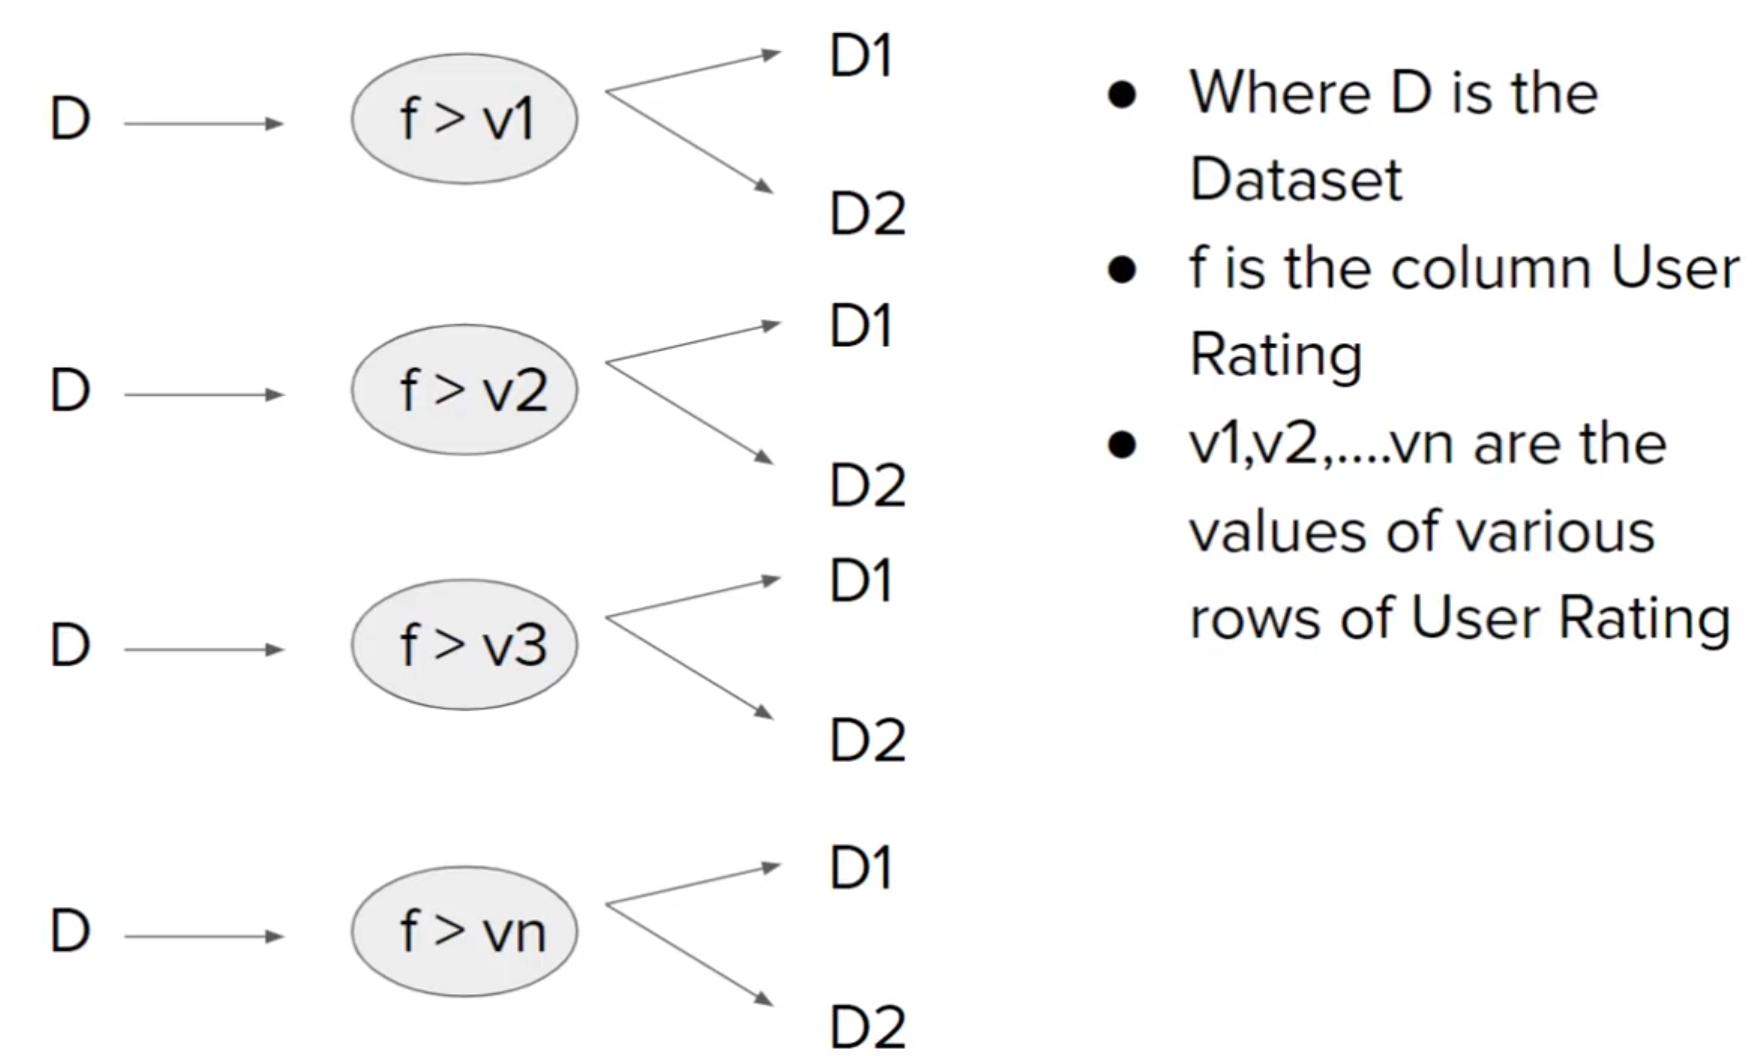

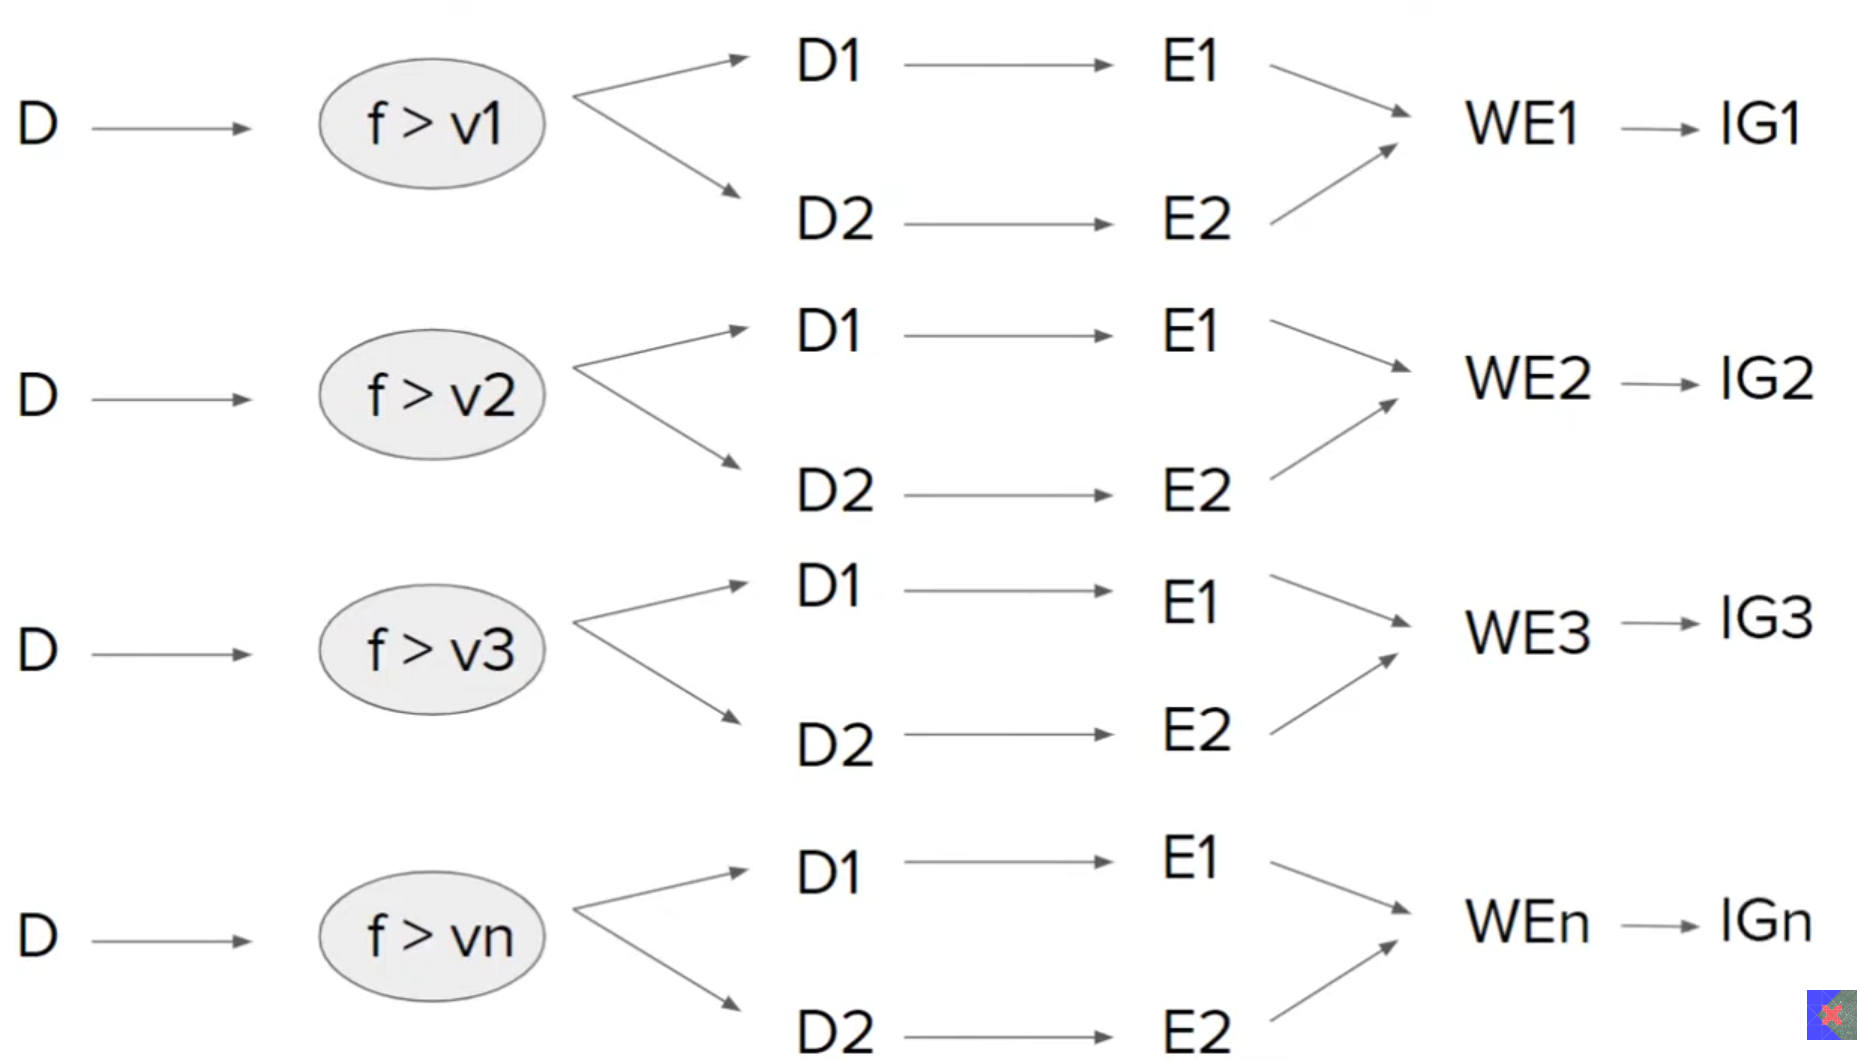

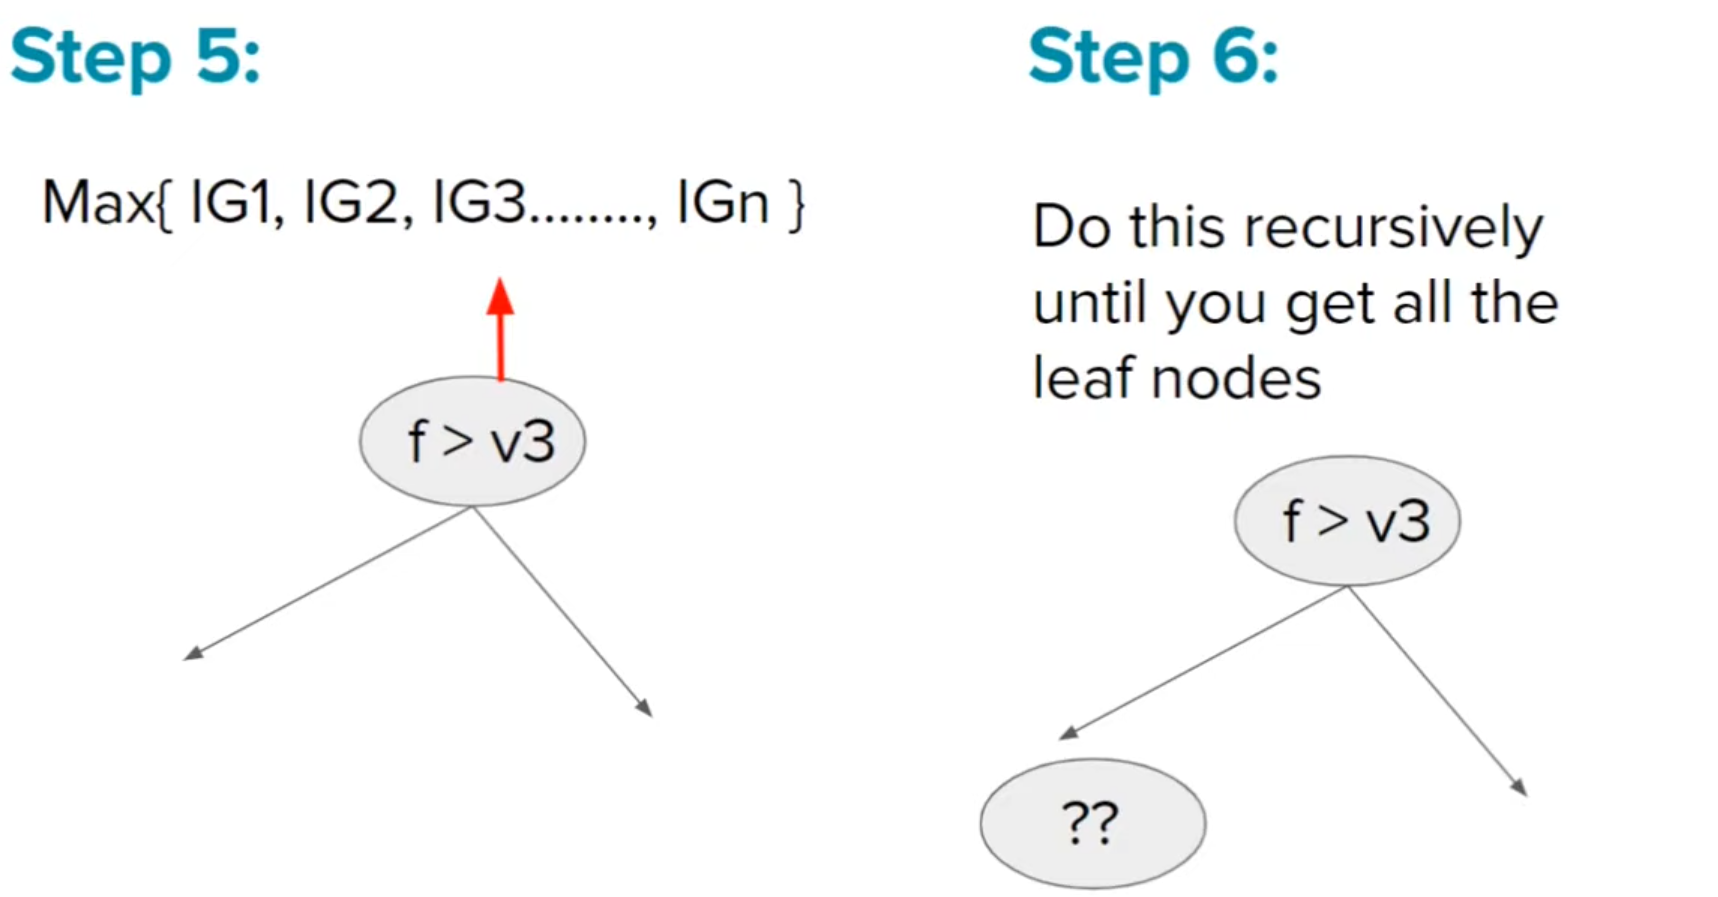

# Example

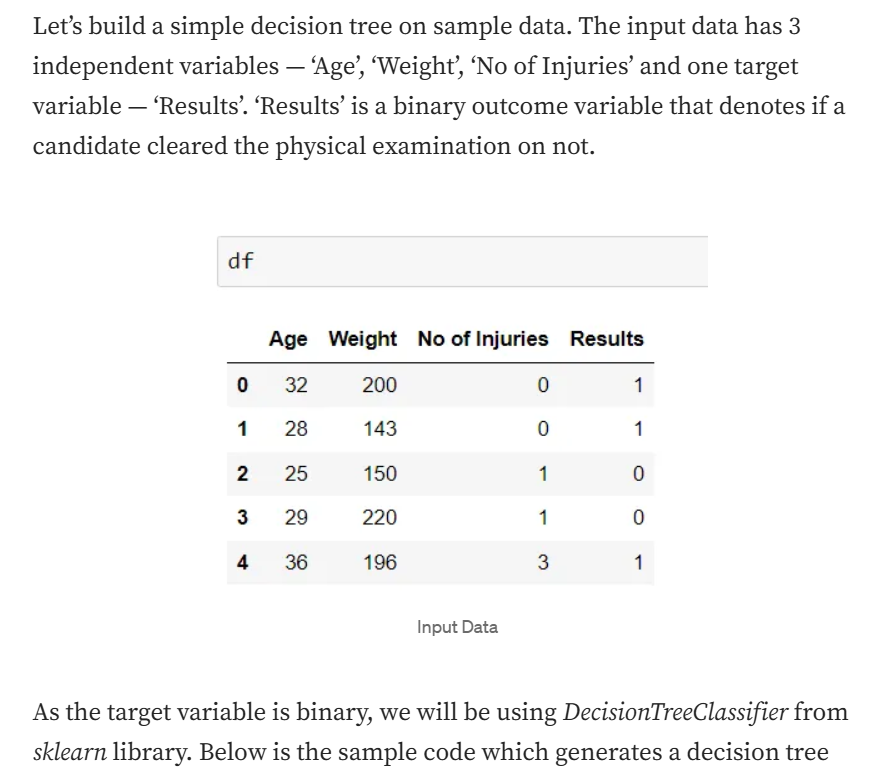

In [5]:
## Importing all the libraries
import pandas as pd
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np

In [6]:
df = pd.read_csv('dataset.csv')

In [7]:
df

,Age,Weight,No of Injuries,Results
0,32,200,0,1
1,28,143,0,1
2,25,150,1,0
3,29,220,1,0
4,36,196,3,1


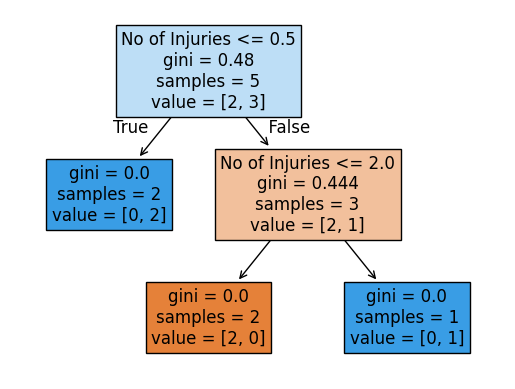

In [8]:
X = df[['Age','Weight','No of Injuries']]
y = df['Results']
features=['Age','Weight','No of Injuries']

## Fitting the model
dtree = DecisionTreeClassifier()
dtree = dtree.fit(X, y)

## Ploting the tree
plot_tree(dtree, feature_names=features, filled=True, fontsize=12)
plt.show()

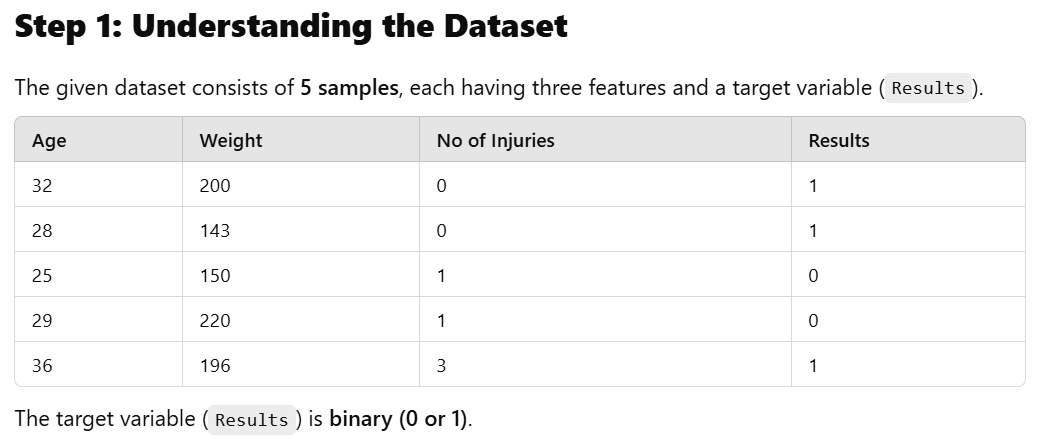

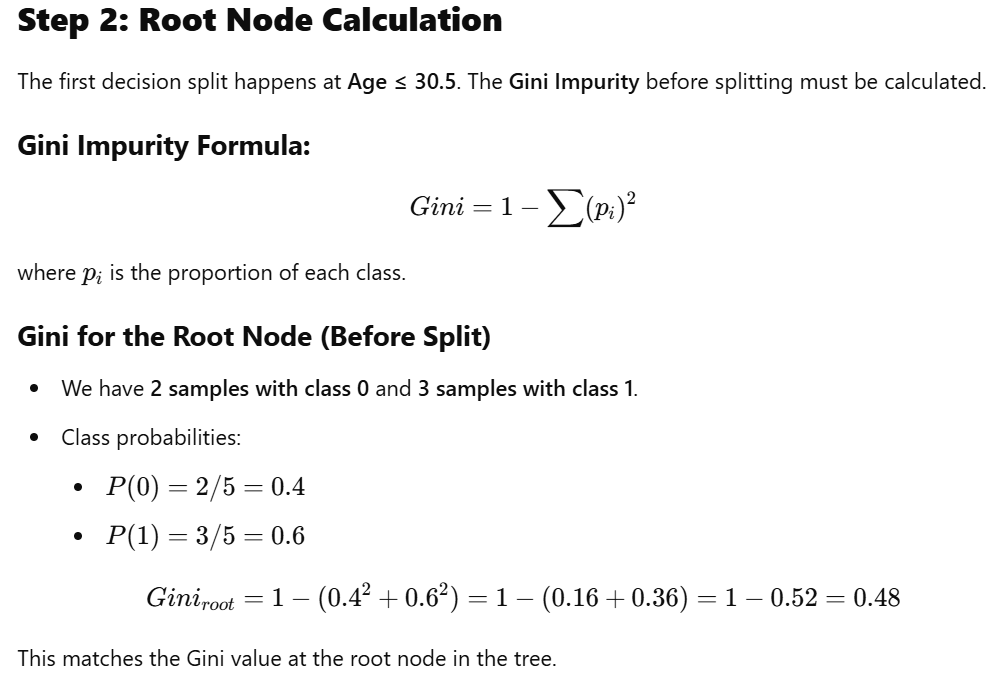

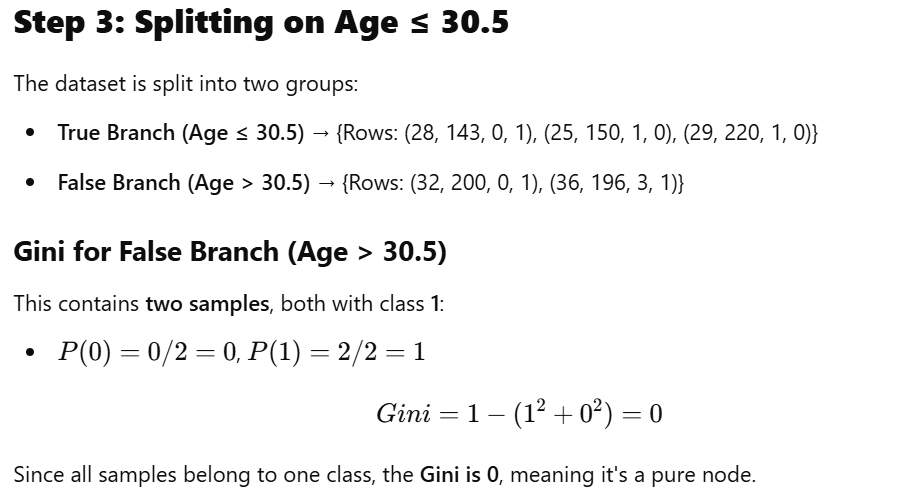

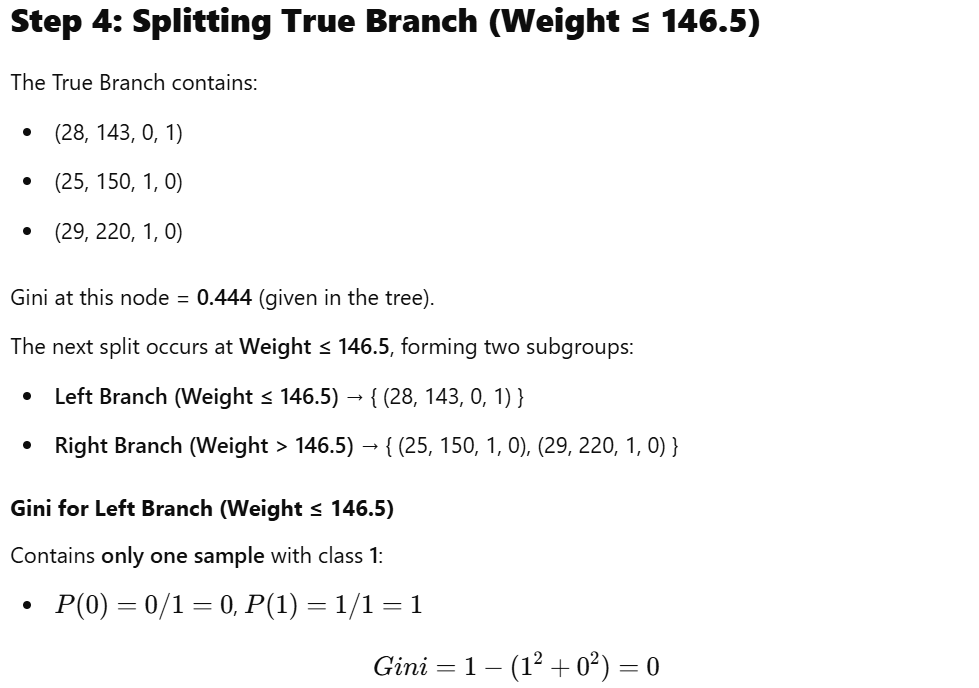

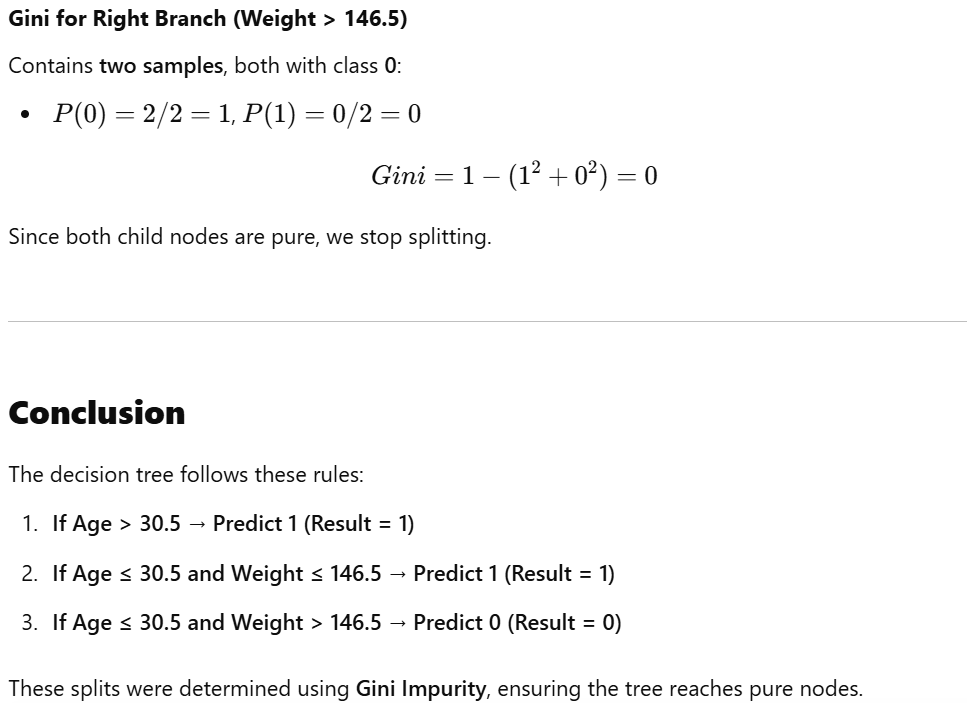

In [9]:
df2 = pd.read_csv('dataset_large.csv')

In [10]:
df2

,Age,Weight,No of Injuries,Exercise Hours/Week,Results
0,58,170,3,8,0
1,48,227,0,6,1
2,34,174,4,8,1
3,27,183,4,7,1
4,40,170,1,1,0
5,58,140,4,0,0
6,38,192,1,6,0
7,42,137,0,6,0
8,30,208,3,7,0
9,30,179,3,4,0


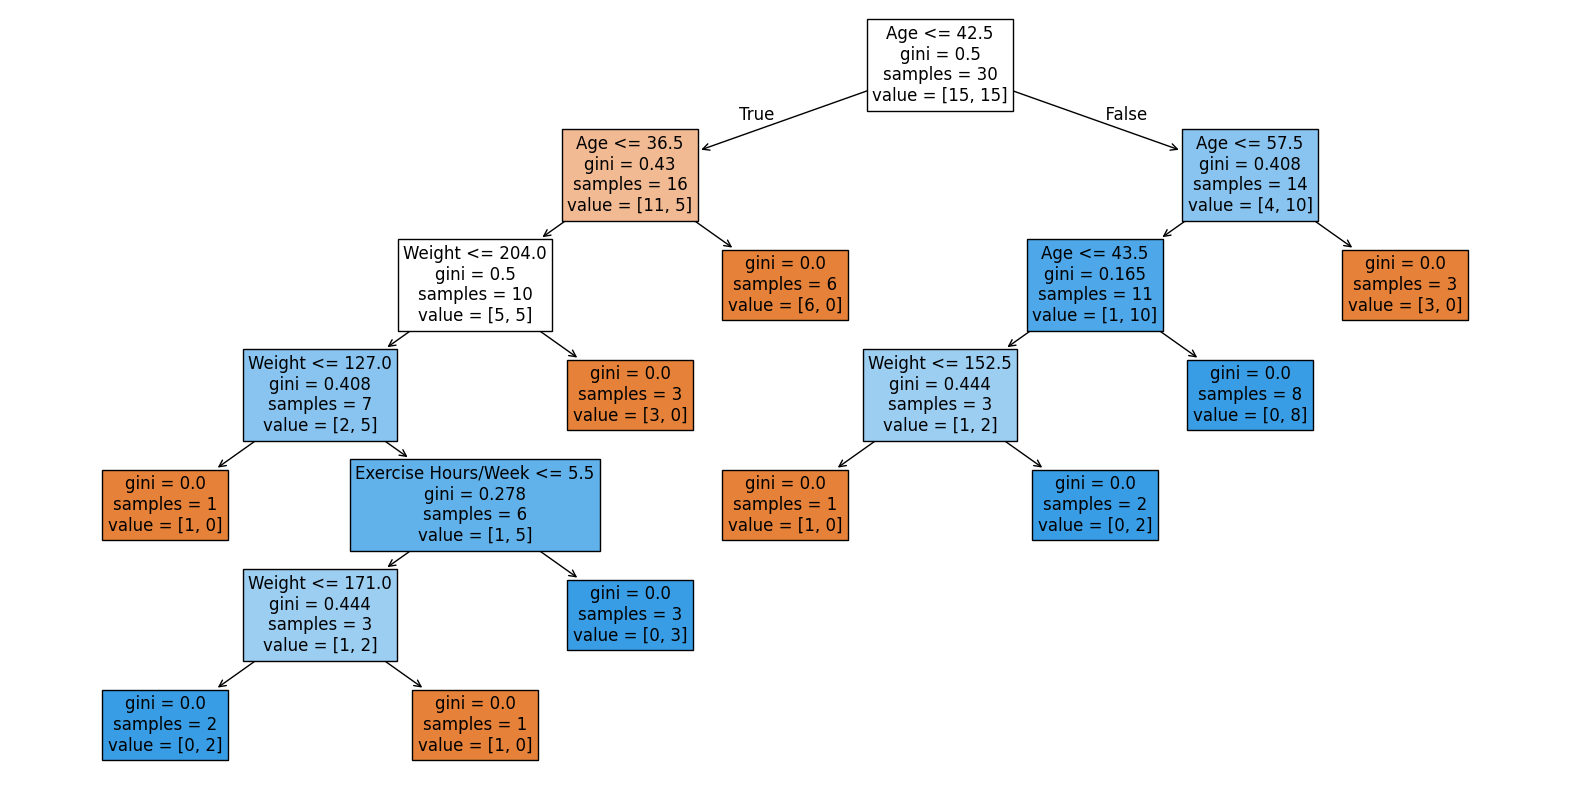

In [11]:
X = df2[['Age','Weight','No of Injuries', 'Exercise Hours/Week']]
y = df2['Results']
features=['Age','Weight','No of Injuries', 'Exercise Hours/Week']

## Fitting the model
dtree = DecisionTreeClassifier()
dtree = dtree.fit(X, y)

# Plotting the tree with a larger figure size
plt.figure(figsize=(20, 10))  # Adjust width and height as needed
plot_tree(dtree, feature_names=features, filled=True, fontsize=12)  # Increase fontsize if needed
plt.show()

# Code Implementation

In [12]:
import numpy as np
import pandas as pd

# Sample dataset
data = {
    "Age": [25, 30, 35, 40, 45],
    "Salary": [40000, 50000, 60000, 80000, 90000],
    "Buys_Car": [1, 0, 0, 1, 1]  # Target variable
}

df = pd.DataFrame(data)
df

,Age,Salary,Buys_Car
0,25,40000,1
1,30,50000,0
2,35,60000,0
3,40,80000,1
4,45,90000,1


In [13]:
# Function to calculate entropy
def entropy(y):
    unique_classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()
    return -np.sum(probabilities * np.log2(probabilities))

In [14]:
# Function to calculate Information Gain
def information_gain(df, feature, target):
    # Calculate parent entropy
    parent_entropy = entropy(df[target])
    
    # Get unique feature values and their splits
    threshold = df[feature].median()
    left_split = df[df[feature] <= threshold]
    right_split = df[df[feature] > threshold]
    
    # Calculate weighted entropy
    left_entropy = entropy(left_split[target])
    right_entropy = entropy(right_split[target])
    
    weighted_entropy = (len(left_split) / len(df) * left_entropy) + \
                       (len(right_split) / len(df) * right_entropy)
    
    # Calculate IG
    ig = parent_entropy - weighted_entropy
    return ig, threshold

In [15]:
# Compute IG for each feature
features = ["Age", "Salary"]
results_entropy = []

for feature in features:
    ig, ig_threshold = information_gain(df, feature, "Buys_Car")
    results_entropy.append({
        "Feature": feature,
        "IG": round(ig, 3),
        "IG Threshold": ig_threshold
    })

In [16]:
# Convert results to DataFrame
results_entropy_df = pd.DataFrame(results_entropy)

In [17]:
# Print results for Entropy and Information Gain
print("Results based on Information Gain:")
print(results_entropy_df)

Results based on Information Gain:
  Feature    IG  IG Threshold
0     Age  0.42          35.0
1  Salary  0.42       60000.0


In [18]:
# Best feature based on IG
best_ig_feature = results_entropy_df.loc[results_entropy_df["IG"].idxmax()]
print("\nBest feature based on IG:", best_ig_feature["Feature"], "with threshold:", best_ig_feature["IG Threshold"])


Best feature based on IG: Age with threshold: 35.0


# Another one

In [19]:
# Updated dataset with a new column "Education_Level"
data = {
    "Age": [23, 37, 21, 24, 31, 45],
    "Salary": [42000, 35000, 24000, 33000, 23000, 33000],
    "Buys_Car": [1, 0, 0, 1, 1, 1],  # Target variable
    "Years_of_Experience": [2, 3, 3, 5, 11, 10] 
}

df = pd.DataFrame(data)
df

,Age,Salary,Buys_Car,Years_of_Experience
0,23,42000,1,2
1,37,35000,0,3
2,21,24000,0,3
3,24,33000,1,5
4,31,23000,1,11
5,45,33000,1,10
